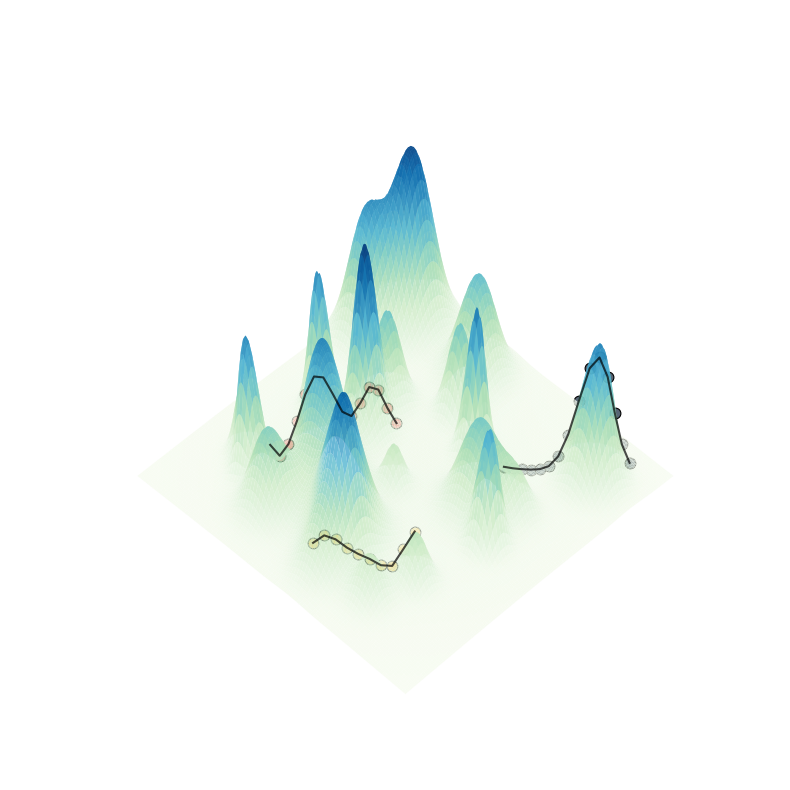

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 1. Generate a "Spiky" Loss Landscape
def generate_landscape(x, y):
    z = np.zeros_like(x)
    
    # A base layer to lift everything slightly
    z += 0.2 * np.exp(-((x)**2 + (y)**2) / (2 * 3.0**2))
    
    # Randomly placed "Sharp" peaks (The Stalagmites)
    np.random.seed(42) # Fixed seed for reproducible look
    num_peaks = 25
    
    for _ in range(num_peaks):
        x0 = np.random.uniform(-2.5, 2.5)
        y0 = np.random.uniform(-2.5, 2.5)
        # Sigma is small (0.15 - 0.3) for sharp spikes
        sigma = np.random.uniform(0.15, 0.35) 
        # Amplitude varies
        amp = np.random.uniform(0.5, 2.5)
        z += amp * np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma**2))
        
    return z

# Higher resolution grid for sharp peaks
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Z = generate_landscape(X, Y)

# 2. Define Trajectories
# We will cheat slightly and "climb" specific peaks we know exist from the seed
# Peak 1 (Red path target): Near (-0.5, 0.5)
path1_x = np.linspace(-1.5, -0.6, 15)
path1_y = np.linspace(-1.5, 0.4, 15)
path1_z = generate_landscape(path1_x, path1_y)

# Peak 2 (Gray path target): Near (1.0, 1.0)
path2_x = np.linspace(2.5, 1.1, 15)
path2_y = np.linspace(2.5, 1.1, 15)
path2_z = generate_landscape(path2_x, path2_y)

# Peak 3 (Yellow path stuck): Near (1.5, -1.5)
path3_x = np.linspace(0.5, 1.6, 10)
path3_y = np.linspace(-2.5, -1.4, 10)
path3_z = generate_landscape(path3_x, path3_y)

# 3. Plotting
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot Surface
# 'GnBu' colormap: Green (low) -> Blue (high)
# alpha=0.4 gives that transparent "ghostly" look
surf = ax.plot_surface(X, Y, Z, cmap=cm.GnBu, alpha=0.8, 
                       linewidth=0, antialiased=True, rstride=2, cstride=2)

# Helper to plot paths with distinct points
def plot_path(ax, px, py, pz, color):
    # This lifts the dots higher so they don't clip into the steep slopes
    lift = 0.02
    
    # Scatter points (nodes)
    ax.scatter(px, py, pz + lift, c=color, s=60, edgecolors='k', linewidth=0.8, depthshade=False, zorder=1)
    # Connect lines (edges)
    ax.plot(px, py, pz + lift, c='k', linewidth=1.5, alpha=0.7, zorder=10)

plot_path(ax, path1_x, path1_y, path1_z, color='#ff6b6b') # Red
plot_path(ax, path2_x, path2_y, path2_z, color='#576574') # Gray
plot_path(ax, path3_x, path3_y, path3_z, color='#feca57') # Yellow

# Styling
ax.set_axis_off()
ax.set_box_aspect(None, zoom=0.9)
ax.view_init(elev=50, azim=-45)
